# Week 6: Graph Analytics — Extracting Graph Structure from Big Data

This notebook works through the key ideas from the Week 6 lecture using real data from **[POGOH](https://pogoh.com/)**, Pittsburgh's bike-share system.

We will turn the raw trip CSV into a **directed, weighted graph** where:
- **Nodes** = bike stations
- **Edges** = trips between stations (weighted by trip count)

Then we will run graph algorithms at scale using **GraphFrames** on top of PySpark.

### What we'll cover
1. Setup — Spark + GraphFrames
2. Load and clean the POGOH dataset
3. Build the station graph (vertices + edges)
4. Basic graph statistics (degree distribution)
5. Centrality — PageRank and Degree Centrality
6. Community detection — Label Propagation (Not very interesting with this data)
7. Motif finding — discovering structural patterns
8. Temporal slice — how the graph changes by time of day

## 1  Setup

GraphFrames is not bundled with PySpark — we load it as a Spark package at session startup.
The `spark.jars.packages` config tells Spark to download the GraphFrames JAR from Maven.

In [1]:
# !pip install pyspark --quiet
# !apt-get update -qq
# !apt install openjdk-17-jdk-headless -qq
import os
os.environ["JAVA_HOME"] = "/opt/anaconda3/envs/cuny312/lib/jvm"

In [3]:
import os, sys
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

os.environ['PYSPARK_PYTHON']        = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

# GraphFrames must be declared at session creation time so Spark downloads the JAR.
# This targets PySpark 3.5 — adjust the version suffix if your Spark version differs.
spark = (
    SparkSession.builder
    .appName("POGOH_Graph")
    .config("spark.jars.packages",
        "graphframes:graphframes:0.8.3-spark3.5-s_2.13")
    .config("spark.sql.shuffle.partitions", "8")   # keep small for local mode
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")  # suppress noisy INFO logs
print("Spark", spark.version)

Spark 4.1.1


In [4]:
from graphframes import GraphFrame
print("GraphFrames imported successfully")

GraphFrames imported successfully


## 2  Load and Clean the POGOH Dataset

The CSV has 1 million+ trip records.  We keep only the columns needed to build the graph
and drop the small fraction of rows that are missing an end station.

In [5]:
CSV_PATH = "../data/pogoh_full.csv"

# If running on Google Colab, mount Drive and update the path:
# from google.colab import drive
# drive.mount('/content/drive')
# CSV_PATH = '/content/drive/MyDrive/...'

raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(CSV_PATH)
)

print(f"{raw.count():,} rows  x  {len(raw.columns)} columns")
raw.printSchema()

1,034,643 rows  x  10 columns
root
 |-- Closed Status: string (nullable = true)
 |-- Duration: integer (nullable = true)
 |-- Start Station Id: integer (nullable = true)
 |-- Start Date: timestamp (nullable = true)
 |-- Start Station Name: string (nullable = true)
 |-- End Date: timestamp (nullable = true)
 |-- End Station Id: integer (nullable = true)
 |-- End Station Name: string (nullable = true)
 |-- Rider Type: string (nullable = true)
 |-- source_file: string (nullable = true)



In [6]:
raw.show(5, truncate=False)

+-------------+--------+----------------+-------------------+---------------------------+-------------------+--------------+--------------------------------------+----------+---------------+
|Closed Status|Duration|Start Station Id|Start Date         |Start Station Name         |End Date           |End Station Id|End Station Name                      |Rider Type|source_file    |
+-------------+--------+----------------+-------------------+---------------------------+-------------------+--------------+--------------------------------------+----------+---------------+
|NORMAL       |299     |51              |2024-04-30 23:53:00|Coltart Ave & Forbes Ave   |2024-04-30 23:58:00|20            |Boulevard of the Allies & Parkview Ave|MEMBER    |april-2024.xlsx|
|NORMAL       |399     |28              |2024-04-30 23:49:00|Fifth Ave & S Bouquet St   |2024-04-30 23:56:00|10            |Zulema St & Coltart Ave               |MEMBER    |april-2024.xlsx|
|NORMAL       |409     |34              |2024

In [7]:
# Rename to friendlier column names and cast End Station Id to integer.
# We also parse the timestamp so we can do time-based slicing later.
trips = (
    raw
    .withColumnRenamed("Start Station Id",   "start_id")
    .withColumnRenamed("Start Station Name", "start_name")
    .withColumnRenamed("End Station Id",     "end_id")
    .withColumnRenamed("End Station Name",   "end_name")
    .withColumnRenamed("Start Date",         "start_time")
    .withColumnRenamed("End Date",           "end_time")
    .withColumnRenamed("Duration",           "duration_sec")
    .withColumnRenamed("Rider Type",         "rider_type")
    .withColumnRenamed("Closed Status",      "status")
    .withColumn("start_id",  F.col("start_id").cast("int"))
    .withColumn("end_id",    F.col("end_id").cast("int"))
    .withColumn("start_time", F.to_timestamp("start_time", "yyyy-MM-dd HH:mm:ss"))
    .withColumn("end_time",   F.to_timestamp("end_time",   "yyyy-MM-dd HH:mm:ss"))
    .select("start_id", "start_name",
            "end_id",   "end_name",
            "duration_sec", "start_time", "rider_type")
    .dropna(subset=["start_id", "end_id"])    # drop the ~0.03% with missing end station
)

trips.cache()   # we will re-use this DataFrame many times
print(f"Clean trips: {trips.count():,}")
trips.show(5)

Clean trips: 1,034,331
+--------+--------------------+------+--------------------+------------+-------------------+----------+
|start_id|          start_name|end_id|            end_name|duration_sec|         start_time|rider_type|
+--------+--------------------+------+--------------------+------------+-------------------+----------+
|      51|Coltart Ave & For...|    20|Boulevard of the ...|         299|2024-04-30 23:53:00|    MEMBER|
|      28|Fifth Ave & S Bou...|    10|Zulema St & Colta...|         399|2024-04-30 23:49:00|    MEMBER|
|      34|N Dithridge St & ...|    20|Boulevard of the ...|         409|2024-04-30 23:46:00|    MEMBER|
|      10|Zulema St & Colta...|    10|Zulema St & Colta...|         348|2024-04-30 23:43:00|    MEMBER|
|      13|S Bouquet Ave & S...|    20|Boulevard of the ...|         248|2024-04-30 23:42:00|    MEMBER|
+--------+--------------------+------+--------------------+------------+-------------------+----------+
only showing top 5 rows


## 3  Build the Station Graph

GraphFrames needs two DataFrames:

| DataFrame | Required columns | What it represents |
|-----------|-----------------|--------------------|
| **vertices** | `id` (any type, must be unique) | one row per node |
| **edges**    | `src`, `dst` (same type as `id`) | one row per directed edge |

Extra columns in either DataFrame are carried along as attributes.

In [8]:
# ── Vertices: one row per unique station ──────────────────────────────────────
start_stations = trips.select(
    F.col("start_id").alias("id"),
    F.col("start_name").alias("name")
)
end_stations = trips.select(
    F.col("end_id").alias("id"),
    F.col("end_name").alias("name")
)

vertices = (
    start_stations.union(end_stations)
    .dropDuplicates(["id"])
    .orderBy("id")
)

print(f"Vertices (stations): {vertices.count()}")
vertices.show(10)

Vertices (stations): 61
+---+--------------------+
| id|                name|
+---+--------------------+
|  1|Pierce St & Summe...|
|  2|Eliza Furnace Tra...|
|  3|Centre Ave & Addi...|
|  4|Burns White Cente...|
|  5|   Allegheny Station|
|  6|  10th St & Penn Ave|
|  7|Liberty Ave & Gro...|
|  8|          Glasshouse|
|  9|South Side Trail ...|
| 10|Zulema St & Colta...|
+---+--------------------+
only showing top 10 rows


In [9]:
# ── Edges: aggregate trip counts into a weighted directed edge list ───────────
# Each (start_id -> end_id) pair becomes one edge with weight = number of trips.
# We also store the mean duration as an edge attribute.
edges = (
    trips
    .groupBy(
        F.col("start_id").alias("src"),
        F.col("end_id").alias("dst")
    )
    .agg(
        F.count("*").alias("trip_count"),
        F.round(F.avg("duration_sec"), 1).alias("avg_duration_sec")
    )
    .filter(F.col("src") != F.col("dst"))   # remove self-loops (maintenance moves)
    .filter(F.col("trip_count") >= 2)        # remove ghost edges (single occurrence)
)

print(f"Edges (station pairs): {edges.count():,}")
edges.orderBy(F.desc("trip_count")).show(10)

Edges (station pairs): 3,188
+---+---+----------+----------------+
|src|dst|trip_count|avg_duration_sec|
+---+---+----------+----------------+
| 20| 13|     21719|           317.1|
| 50| 13|     19084|           209.4|
| 13| 50|     18964|           220.6|
| 13| 20|     18365|           336.9|
| 34| 12|     17433|           246.0|
| 12| 34|     15811|           243.3|
| 13| 10|     12936|           288.5|
| 10| 13|     11880|           295.3|
| 51| 13|      8873|           275.1|
| 51| 10|      8118|           183.4|
+---+---+----------+----------------+
only showing top 10 rows


In [10]:
# ── Create the GraphFrame ─────────────────────────────────────────────────────
g = GraphFrame(vertices, edges)
print(g)

GraphFrame(v:[id: int, name: string], e:[src: int, dst: int ... 2 more fields])


## 4  Basic Graph Statistics

Before running any algorithms, get a feel for the graph's structure.

In [11]:
# Node and edge counts
n_nodes = g.vertices.count()
n_edges = g.edges.count()
print(f"Nodes : {n_nodes}")
print(f"Edges : {n_edges}")
print(f"Density (edges / max possible): {n_edges / (n_nodes * (n_nodes - 1)):.3f}")

Nodes : 61
Edges : 3188
Density (edges / max possible): 0.871


In [12]:
# Degree: GraphFrames computes in-degree, out-degree, and total degree
degrees = (
    g.degrees
    .join(g.vertices, on="id")
    .orderBy(F.desc("degree"))
)

print("Top 10 stations by total degree (in + out edges):")
degrees.show(10, truncate=False)

Top 10 stations by total degree (in + out edges):
+---+------+----------------------------------------+
|id |degree|name                                    |
+---+------+----------------------------------------+
|28 |118   |Fifth Ave & S Bouquet St                |
|26 |117   |S 27th St & Sidney St. (Southside Works)|
|11 |117   |Ellsworth Ave & N Neville St            |
|37 |117   |S Negley Ave & Centre Ave               |
|33 |116   |Schenley Dr & Schenley Dr Ext           |
|13 |116   |S Bouquet Ave & Sennott St              |
|51 |116   |Coltart Ave & Forbes Ave                |
|17 |116   |Taylor St & Liberty Ave                 |
|29 |116   |Forbes Ave & Schenley Dr                |
|15 |116   |Ivy St & Walnut St                      |
+---+------+----------------------------------------+
only showing top 10 rows


In [13]:
# In-degree vs out-degree: does a station receive more trips than it sends?
# Imbalance indicates a net source (more departures) or sink (more arrivals).
# Use SQL to avoid Spark 4.x self-join ExprId ambiguity when all three DataFrames derive from the same GraphFrame.
g.inDegrees.withColumnRenamed("inDegree", "in_degree").createOrReplaceTempView("_in_deg")
g.outDegrees.withColumnRenamed("outDegree", "out_degree").createOrReplaceTempView("_out_deg")
g.vertices.select("id", "name").createOrReplaceTempView("_verts")

in_out = spark.sql("""
    SELECT i.id, v.name, i.in_degree, o.out_degree,
           (i.in_degree - o.out_degree) AS imbalance
    FROM _in_deg i
    JOIN _out_deg o ON i.id = o.id
    JOIN _verts   v ON i.id = v.id
    ORDER BY ABS(i.in_degree - o.out_degree) DESC
""")

print("Stations with the largest in/out imbalance (net sinks or sources):")
in_out.show(10, truncate=False)

Stations with the largest in/out imbalance (net sinks or sources):
+---+------------------------------------+---------+----------+---------+
|id |name                                |in_degree|out_degree|imbalance|
+---+------------------------------------+---------+----------+---------+
|42 |Second Ave & Tecumseh St            |47       |36        |11       |
|27 |W Station Square Dr & Bessemer Court|50       |45        |5        |
|3  |Centre Ave & Addison St             |48       |53        |-5       |
|52 |Bedford Ave & Memory Ln             |42       |47        |-5       |
|55 |Brighton Rd & Pennsylvania Ave      |51       |46        |5        |
|38 |Allequippa St & Darragh St          |53       |57        |-4       |
|44 |Hamilton Ave & Fifth Ave            |44       |40        |4        |
|43 |Eliza St & Lytle St                 |36       |32        |4        |
|12 |O'Hara St and University Place      |54       |57        |-3       |
|10 |Zulema St & Coltart Ave             |55 

In [14]:
# Edge weight distribution -- how concentrated is traffic?
print("Trip count distribution across edges:")
edges.select("trip_count").describe().show()

# What share of total trips does the top 10% of edges carry?
total_trips = edges.agg(F.sum("trip_count")).collect()[0][0]
threshold   = edges.approxQuantile("trip_count", [0.90], 0.01)[0]
top10_trips = edges.filter(F.col("trip_count") >= threshold).agg(F.sum("trip_count")).collect()[0][0]
print(f"\nTop 10% of edges carry {top10_trips/total_trips*100:.1f}% of total trips")

Trip count distribution across edges:
+-------+------------------+
|summary|        trip_count|
+-------+------------------+
|  count|              3188|
|   mean|287.75878293601005|
| stddev|1094.3697390133057|
|    min|                 2|
|    max|             21719|
+-------+------------------+


Top 10% of edges carry 73.2% of total trips


## 5  Centrality — Measuring Station Importance

### Degree Centrality
The simplest measure: a station is important if many other stations connect to it.

### PageRank
A more sophisticated measure: a station is important if *important* stations send trips to it.
Mathematically:

$$PR(u) = \frac{1-d}{N} + d \sum_{v \in B_u} \frac{PR(v)}{L(v)}$$

where $d$ is the damping factor (default 0.85), $B_u$ is the set of stations that send trips **to** $u$,
and $L(v)$ is the out-degree of station $v$.

In [15]:
# PageRank -- converge to tolerance 0.01
pr = g.pageRank(resetProbability=0.15, tol=0.01)

pr_results = (
    pr.vertices
    .select("id", "name", F.round("pagerank", 4).alias("pagerank"))
    .orderBy(F.desc("pagerank"))
)

print("Top 10 stations by PageRank (flow-based influence):")
pr_results.show(10, truncate=False)

Top 10 stations by PageRank (flow-based influence):
+---+----------------------------------------+--------+
|id |name                                    |pagerank|
+---+----------------------------------------+--------+
|28 |Fifth Ave & S Bouquet St                |1.1153  |
|33 |Schenley Dr & Schenley Dr Ext           |1.1005  |
|59 |Forbes Ave at TCS Hall (CMU Campus)     |1.0975  |
|23 |North Shore Trail & Fort Duquesne Bridge|1.0974  |
|40 |7th St & Penn Ave                       |1.0974  |
|24 |Penn Ave & 33rd St                      |1.0964  |
|26 |S 27th St & Sidney St. (Southside Works)|1.0963  |
|11 |Ellsworth Ave & N Neville St            |1.0963  |
|7  |Liberty Ave & Gross St                  |1.0961  |
|29 |Forbes Ave & Schenley Dr                |1.096   |
+---+----------------------------------------+--------+
only showing top 10 rows


In [16]:
# Compare PageRank rank vs. raw degree rank
# A station that is high on PageRank but lower on degree is influential
# because it attracts trips FROM well-connected stations.
degree_rank  = degrees.select("id", "name", "degree").limit(15)
pagerank_top = pr_results.limit(15)

print("-- Degree rank (top 15) --")
degree_rank.show(15, truncate=False)

print("-- PageRank rank (top 15) --")
pagerank_top.show(15, truncate=False)

-- Degree rank (top 15) --
+---+----------------------------------------+------+
|id |name                                    |degree|
+---+----------------------------------------+------+
|28 |Fifth Ave & S Bouquet St                |118   |
|26 |S 27th St & Sidney St. (Southside Works)|117   |
|11 |Ellsworth Ave & N Neville St            |117   |
|37 |S Negley Ave & Centre Ave               |117   |
|13 |S Bouquet Ave & Sennott St              |116   |
|17 |Taylor St & Liberty Ave                 |116   |
|51 |Coltart Ave & Forbes Ave                |116   |
|33 |Schenley Dr & Schenley Dr Ext           |116   |
|24 |Penn Ave & 33rd St                      |116   |
|29 |Forbes Ave & Schenley Dr                |116   |
|15 |Ivy St & Walnut St                      |116   |
|59 |Forbes Ave at TCS Hall (CMU Campus)     |116   |
|40 |7th St & Penn Ave                       |115   |
|23 |North Shore Trail & Fort Duquesne Bridge|115   |
|7  |Liberty Ave & Gross St                  |115   |
+

## 6  Connected Components

A **connected component** is a subgraph where every node can reach every other node
(ignoring edge direction).  Isolated stations or groups show up as separate components.

GraphFrames uses an optimised distributed BFS — equivalent to running `spark.graphx.ConnectedComponents`
but from Python with a DataFrame API.

In [17]:
# GraphFrames' connectedComponents() calls SparkSession.implicits() internally, which was removed in Spark 4.0 — it raises NoSuchMethodError at runtime.
# Workaround: collect the edge list and run connected components via NetworkX. This is fine here because the station graph has only ~200 nodes.
import networkx as nx

edges_local = g.edges.select("src", "dst").collect()
G_nx = nx.from_edgelist([(r.src, r.dst) for r in edges_local])  # undirected

components     = list(nx.connected_components(G_nx))
component_df   = [{"component": i, "size": len(c)} for i, c in enumerate(components)]
component_df.sort(key=lambda x: -x["size"])

print(f"Number of connected components: {len(component_df)}")
for row in component_df[:10]:
    print(f"  component {row['component']:3d}  —  {row['size']} stations")

Number of connected components: 1
  component   0  —  60 stations


In [19]:
# Get the node IDs in the largest component
main_idx   = component_df[0]["component"]   # index into the original components list
main_nodes = components[main_idx]

# Map IDs back to names using the vertices DataFrame
id_to_name = {row.id: row.name for row in g.vertices.collect()}

print(f"Stations in main component ({len(main_nodes)} total):")
for station_id in sorted(main_nodes)[:20]:
    print(f"  {station_id}\t{id_to_name.get(station_id, '?')}")


Stations in main component (60 total):
  1	Pierce St & Summerlea St
  2	Eliza Furnace Trail & Swineburne St
  3	Centre Ave & Addison St
  4	Burns White Center at 3 Crossings
  5	Allegheny Station
  6	10th St & Penn Ave
  7	Liberty Ave & Gross St
  8	Glasshouse
  9	South Side Trail & S 4th St
  10	Zulema St & Coltart Ave
  11	Ellsworth Ave & N Neville St
  12	O'Hara St and University Place
  13	S Bouquet Ave & Sennott St
  14	Tioga St & N Homewood Ave
  15	Ivy St & Walnut St
  16	Penn Ave & Putnam St (Bakery Square)
  17	Taylor St & Liberty Ave
  18	21st St & Penn Ave
  19	42nd St & Butler St
  20	Boulevard of the Allies & Parkview Ave


## 7  Community Detection — Label Propagation

Label Propagation (LPA) is an iterative algorithm that detects communities by spreading
labels through the graph.  Each node adopts the label held by the majority of its neighbours.
Stations that form tight clusters ("bike neighbourhoods") converge to the same label.

> **Note**: LPA is non-deterministic — results may vary between runs.

In [20]:
communities = g.labelPropagation(maxIter=5)

community_sizes = (
    communities
    .groupBy("label")
    .agg(F.count("*").alias("size"))
    .orderBy(F.desc("size"))
)

print(f"Number of communities detected: {community_sizes.count()}")
print("\nTop communities by size:")
community_sizes.show(10)

Number of communities detected: 2

Top communities by size:
+-----+----+
|label|size|
+-----+----+
|    1|  60|
|   61|   1|
+-----+----+



In [21]:
# Inspect the largest community
top_label = community_sizes.first()["label"]

print("Stations in the largest community:")
communities.filter(F.col("label") == top_label) \
           .select("id", "name") \
           .orderBy("id") \
           .show(30, truncate=False)

Stations in the largest community:
+---+----------------------------------------+
|id |name                                    |
+---+----------------------------------------+
|1  |Pierce St & Summerlea St                |
|2  |Eliza Furnace Trail & Swineburne St     |
|3  |Centre Ave & Addison St                 |
|4  |Burns White Center at 3 Crossings       |
|5  |Allegheny Station                       |
|6  |10th St & Penn Ave                      |
|7  |Liberty Ave & Gross St                  |
|8  |Glasshouse                              |
|9  |South Side Trail & S 4th St             |
|10 |Zulema St & Coltart Ave                 |
|11 |Ellsworth Ave & N Neville St            |
|12 |O'Hara St and University Place          |
|13 |S Bouquet Ave & Sennott St              |
|14 |Tioga St & N Homewood Ave               |
|15 |Ivy St & Walnut St                      |
|16 |Penn Ave & Putnam St (Bakery Square)    |
|17 |Taylor St & Liberty Ave                 |
|18 |21st St & Penn Ave  

In [22]:
# DIFFERENT APPROACH: use NetworkX's Louvain method for community detection, which is more robust than label propagation.
louvain_comms = nx.community.louvain_communities(G_nx, seed=42)
louvain_comms.sort(key=len, reverse=True)

print(f"Communities found: {len(louvain_comms)}")
for i, comm in enumerate(louvain_comms[:5]):
    names = sorted(id_to_name.get(n, str(n)) for n in comm)
    print(f"\nCommunity {i+1} ({len(comm)} stations): {', '.join(names[:5])}{'...' if len(names) > 5 else ''}")


Communities found: 2

Community 1 (34 stations): 10th St & Penn Ave, 17th St & Penn Ave, 21st St & Penn Ave, 7th St & Penn Ave, Allegheny Station...

Community 2 (26 stations): 42nd St & Butler St, 52nd St & Butler St, Bedford Ave & Memory Ln, Ellsworth Ave & N Neville St, Fifth Ave & S Bouquet St...


## 8  Motif Finding — Structural Pattern Matching

**Motifs** let you query the graph topology using a pattern mini-language.
Each named variable (e.g., `a`, `b`) binds to a vertex; each named edge (e.g., `e1`) binds to an edge.

```
(a)-[e1]->(b)-[e2]->(c)   # three-hop path
(a)-[e1]->(b); (b)-[e2]->(a)  # mutual edge (a <-> b)
```

The result is a DataFrame where each column corresponds to a bound vertex or edge.

In [23]:
# Mutual edges: station pairs where trips flow in BOTH directions.
# (a) -> (b) AND (b) -> (a)
mutual = g.find("(a)-[e1]->(b); (b)-[e2]->(a)")

mutual_clean = (
    mutual
    .select(
        F.col("a.name").alias("station_A"),
        F.col("b.name").alias("station_B"),
        F.col("e1.trip_count").alias("A_to_B"),
        F.col("e2.trip_count").alias("B_to_A"),
    )
    .filter(F.col("station_A") < F.col("station_B"))  # deduplicate pairs
    .withColumn("total_flow", F.col("A_to_B") + F.col("B_to_A"))
    .orderBy(F.desc("total_flow"))
)

print(f"Mutual-edge pairs: {mutual_clean.count()}")
print("\nTop 10 bidirectional corridors by total trips:")
mutual_clean.show(10, truncate=False)

Mutual-edge pairs: 1537

Top 10 bidirectional corridors by total trips:
+--------------------------------------+------------------------------+------+------+----------+
|station_A                             |station_B                     |A_to_B|B_to_A|total_flow|
+--------------------------------------+------------------------------+------+------+----------+
|Boulevard of the Allies & Parkview Ave|S Bouquet Ave & Sennott St    |21719 |18365 |40084     |
|Atwood St & Bates St                  |S Bouquet Ave & Sennott St    |19084 |18964 |38048     |
|N Dithridge St & Centre Ave           |O'Hara St and University Place|17433 |15811 |33244     |
|S Bouquet Ave & Sennott St            |Zulema St & Coltart Ave       |12936 |11880 |24816     |
|Coltart Ave & Forbes Ave              |S Bouquet Ave & Sennott St    |8873  |8019  |16892     |
|Coltart Ave & Forbes Ave              |Zulema St & Coltart Ave       |8118  |7777  |15895     |
|Atwood St & Bates St                  |Fifth Ave & S B

In [24]:
# Triangle motif: find stations that form a tight triangle A -> B -> C -> A.
# These represent tight mobility clusters.
triangles = g.find("(a)-[e1]->(b); (b)-[e2]->(c); (c)-[e3]->(a)")

triangle_summary = (
    triangles
    .select(
        F.col("a.name").alias("A"),
        F.col("b.name").alias("B"),
        F.col("c.name").alias("C"),
        (F.col("e1.trip_count") +
         F.col("e2.trip_count") +
         F.col("e3.trip_count")).alias("total_flow")
    )
    .orderBy(F.desc("total_flow"))
)

print("Top triangles by total trip volume:")
triangle_summary.show(10, truncate=False)

Top triangles by total trip volume:
+--------------------------------------+--------------------------------------+--------------------------------------+----------+
|A                                     |B                                     |C                                     |total_flow|
+--------------------------------------+--------------------------------------+--------------------------------------+----------+
|Atwood St & Bates St                  |Boulevard of the Allies & Parkview Ave|S Bouquet Ave & Sennott St            |46394     |
|Boulevard of the Allies & Parkview Ave|S Bouquet Ave & Sennott St            |Atwood St & Bates St                  |46394     |
|S Bouquet Ave & Sennott St            |Atwood St & Bates St                  |Boulevard of the Allies & Parkview Ave|46394     |
|S Bouquet Ave & Sennott St            |Boulevard of the Allies & Parkview Ave|Atwood St & Bates St                  |41507     |
|Boulevard of the Allies & Parkview Ave|Atwood St & Ba

## 9  Temporal Slice — How the Graph Changes by Hour

A single static graph hides important dynamics.  We build two sub-graphs — one for
**morning rush hour** (7–9 AM) and one for **evening rush hour** (17–19)  — and compare
their top PageRank stations.

This is an example of the *Temporal Graph Considerations* from the lecture: static
aggregation vs. time-sliced analysis.

In [25]:
def build_graph(trip_df):
    """Build a GraphFrame from a filtered trips DataFrame."""
    verts = (
        trip_df.select(F.col("start_id").alias("id"), F.col("start_name").alias("name"))
        .union(trip_df.select(F.col("end_id").alias("id"), F.col("end_name").alias("name")))
        .dropDuplicates(["id"])
    )
    edgs = (
        trip_df
        .groupBy(F.col("start_id").alias("src"), F.col("end_id").alias("dst"))
        .agg(F.count("*").alias("trip_count"))
        .filter(F.col("src") != F.col("dst"))
    )
    return GraphFrame(verts, edgs)


trips_am = trips.filter((F.hour("start_time") >= 7) & (F.hour("start_time") < 9))
trips_pm = trips.filter((F.hour("start_time") >= 17) & (F.hour("start_time") < 19))

g_am = build_graph(trips_am)
g_pm = build_graph(trips_pm)

print(f"AM graph: {g_am.vertices.count()} nodes, {g_am.edges.count()} edges")
print(f"PM graph: {g_pm.vertices.count()} nodes, {g_pm.edges.count()} edges")

AM graph: 60 nodes, 2095 edges
PM graph: 60 nodes, 2798 edges


In [26]:
# PageRank on each time-slice graph
def top_pagerank(graph, label, n=10):
    pr = graph.pageRank(resetProbability=0.15, tol=0.01)
    print(f"\n=== {label} — Top {n} PageRank ===")
    pr.vertices.select("name", F.round("pagerank", 4).alias("pagerank")) \
               .orderBy(F.desc("pagerank")) \
               .show(n, truncate=False)

top_pagerank(g_am, "Morning rush (7–9 AM)")
top_pagerank(g_pm, "Evening rush (5–7 PM)")


=== Morning rush (7–9 AM) — Top 10 PageRank ===
+----------------------------------------+--------+
|name                                    |pagerank|
+----------------------------------------+--------+
|7th St & Penn Ave                       |1.453   |
|S 27th St & Sidney St. (Southside Works)|1.4262  |
|Ross St & Fourth Ave                    |1.4057  |
|Fifth Ave & S Bouquet St                |1.3617  |
|Liberty Ave & Stanwix St                |1.3509  |
|Forbes Ave & Market Square              |1.3468  |
|First Ave & B St                        |1.3225  |
|Forbes Ave & Schenley Dr                |1.3153  |
|O'Hara St and University Place          |1.3142  |
|10th St & Penn Ave                      |1.3078  |
+----------------------------------------+--------+
only showing top 10 rows

=== Evening rush (5–7 PM) — Top 10 PageRank ===
+----------------------------------------+--------+
|name                                    |pagerank|
+----------------------------------------+---

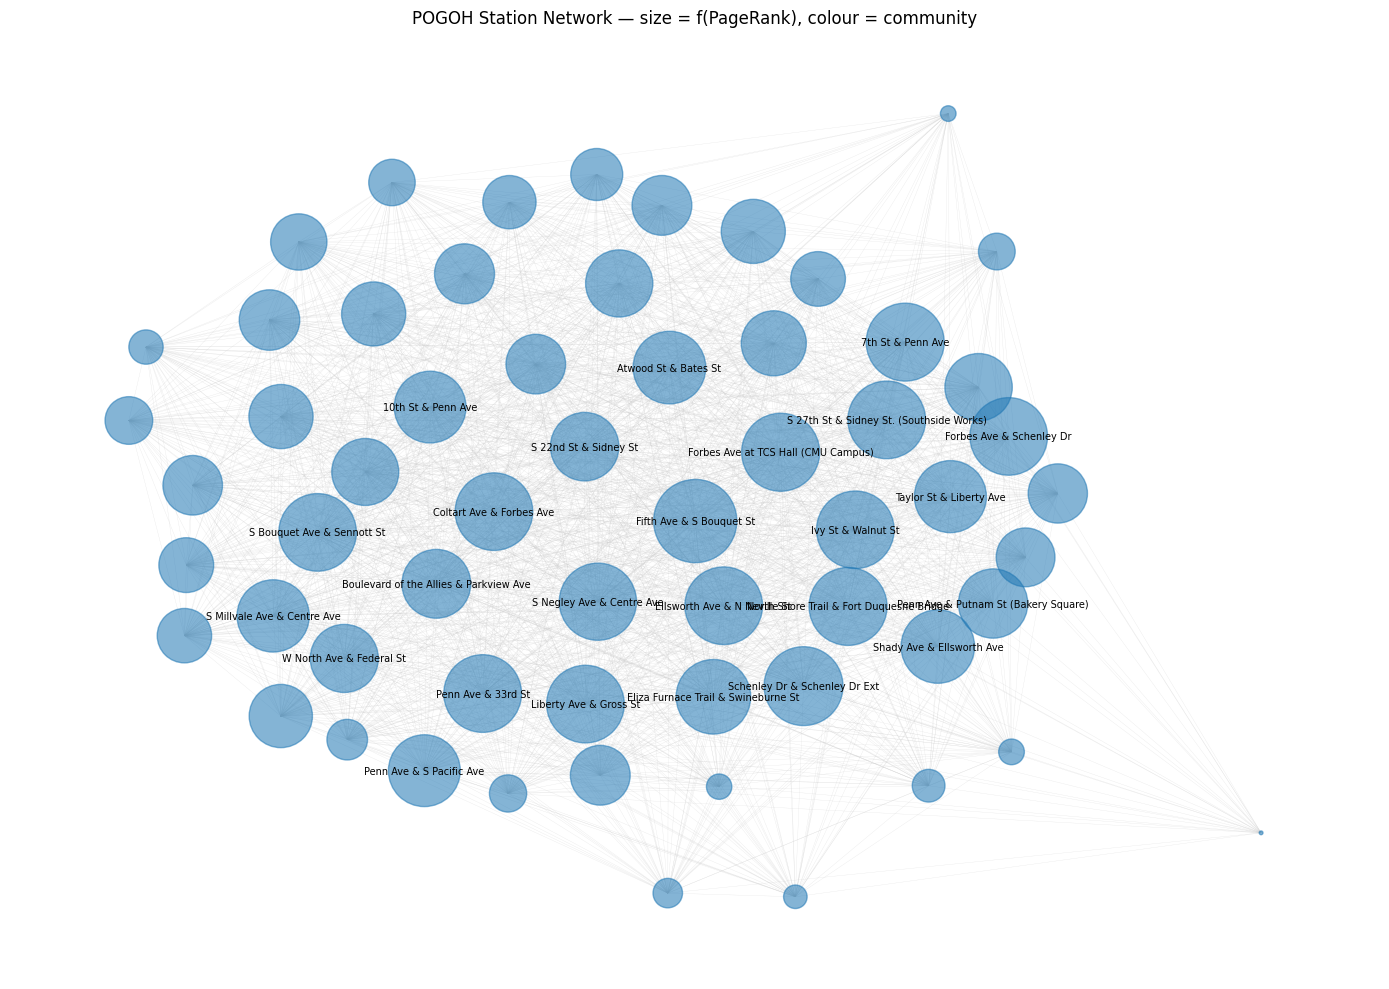

26/03/17 21:17:43 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:707)
	at org.apache.spark.storage.BlockManagerMasterE

In [ ]:
import matplotlib.pyplot as plt

# Collect results computed earlier
pr_map   = {row.id: row.pagerank for row in pr_results.collect()}
comm_map = {row.id: row.label    for row in communities.collect()}
id_to_name = {row.id: row.name   for row in g.vertices.collect()}

for n in G_nx.nodes:
    G_nx.nodes[n]["pagerank"]  = pr_map.get(n, 0.0)
    G_nx.nodes[n]["community"] = comm_map.get(n, 0)

pos         = nx.kamada_kawai_layout(G_nx)
node_sizes  = [G_nx.nodes[n]["pagerank"]**8 * 1500 for n in G_nx.nodes]
unique_comm = list({G_nx.nodes[n]["community"] for n in G_nx.nodes})
palette     = {c: i for i, c in enumerate(unique_comm)}
node_colors = [palette[G_nx.nodes[n]["community"]] for n in G_nx.nodes]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx(G_nx, pos, ax=ax,
                 node_size=node_sizes, node_color=node_colors,
                 cmap="tab20", edge_color="#cccccc", width=0.2,
                 with_labels=False, alpha=0.55)

# Label top-25 PageRank stations only
top25 = sorted(pr_map, key=pr_map.get, reverse=True)[:25]
nx.draw_networkx_labels(G_nx, pos, ax=ax,
    labels={n: id_to_name.get(n, str(n)) for n in top25}, font_size=7)

ax.set_title("POGOH Station Network — size = f(PageRank), colour = community")
ax.axis("off")
plt.tight_layout()
plt.show()
